 Eigen values of A 
[-0.5+3.122499j -0.5-3.122499j]


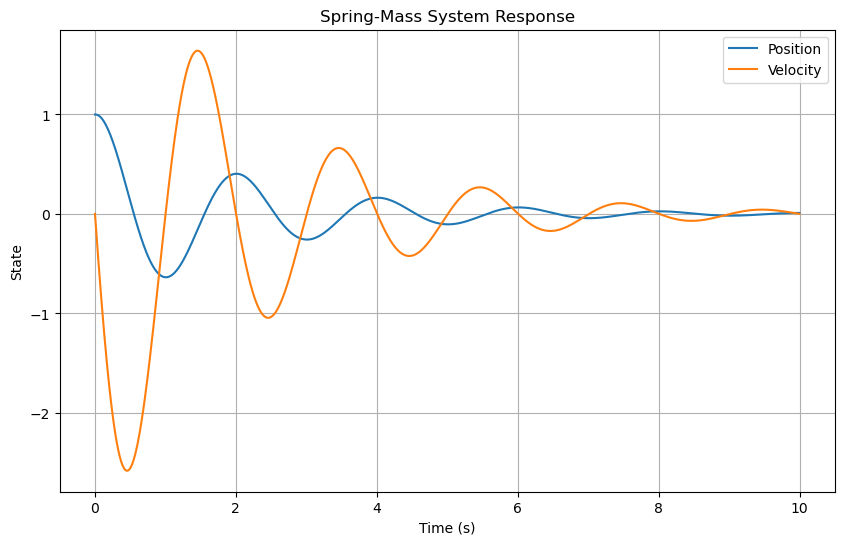

In [12]:
# Euler integration loop
import numpy as np
import matplotlib.pyplot as plt

# System parameters
m = 1       # mass in kg
k = 10      # spring constant in N/m
c = 1     # damping co-effiecent
A = np.array([[0, 1], [-k/m, -c/m]])  # System matrix
eigenvalues = np.linalg.eigvals(A)
print(" Eigen values of A " )
print (eigenvalues)
# Simulation parameters
dt = 0.01   # time step
t_end = 10  # end time
steps = int(t_end/dt)

# Initial conditions (position and velocity)
x = np.array([1.0, 0.0])  # Initial displacement = 1, initial velocity = 0

# Arrays to store results
t_values = np.zeros(steps+1)
x_values = np.zeros((steps+1, 2))
x_values[0] = x  # Store initial state

# Euler integration loop
for i in range(steps):
    x_new = x + dt*(A@x)  # Euler integration step: x_new = x + dt*(A@x)
    x = x_new  # Update state for next iteration
    t_values[i+1] = (i+1)*dt  # Update time
    x_values[i+1] = x  # Store state

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(t_values, x_values[:, 0], label='Position')
plt.plot(t_values, x_values[:, 1], label='Velocity')
plt.xlabel('Time (s)')
plt.ylabel('State')
plt.title('Spring-Mass System Response')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# For matrix inversion
B = np.linalg.inv(A)  # Use np.linalg.inv instead of np.inv

print("\nInverse Matrix B:")
print(B)

# For calculating determinant
det_A = np.linalg.det(A)  # This calculates the determinant of matrix A
print("\nDeterminant of A:")
print(det_A)

# Verify that A*B = I (identity matrix)
I_check = np.dot(A, B)
print("\nA*B (should be close to identity matrix):")
print(I_check)

eigens = np.linalg.eig (A)
print("\n Eigne values of A matrix ")
print(eigens)


Inverse Matrix B:
[[-0.01408451  0.11267606]
 [ 0.12676056 -0.01408451]]

Determinant of A:
-71.0

A*B (should be close to identity matrix):
[[1. 0.]
 [0. 1.]]

 Eigne values of A matrix 
EigResult(eigenvalues=array([ 9.48528137, -7.48528137]), eigenvectors=array([[ 0.68599434, -0.68599434],
       [ 0.72760688,  0.72760688]]))


In [14]:
import numpy as np
from typing import Union, Tuple, List, Any

def is_stable(matrix: np.ndarray) -> Tuple[bool, dict]:
    """
    Check if a matrix is stable by examining its eigenvalues.
    
    A matrix is considered stable if all eigenvalues have negative real parts.
    
    Args:
        matrix: Input square matrix to analyze for stability
        
    Returns:
        Tuple containing:
            - Boolean indicating if the matrix is stable
            - Dictionary with additional information:
                - 'eigenvalues': The eigenvalues of the matrix
                - 'determinant': The determinant of the matrix
                - 'inverse': The inverse of the matrix (if it exists)
                - 'verification': The product of matrix and its inverse
    """
    # Calculate eigenvalues
    eigenvalues, eigenvectors = np.linalg.eig(matrix)
    
    # Check stability (all eigenvalues must have negative real parts)
    is_stable_system = all(eigenvalue.real < 0 for eigenvalue in eigenvalues)
    
    # Additional information
    result_info = {
        'eigenvalues': eigenvalues,
        'determinant': np.linalg.det(matrix)
    }
    
    # Calculate inverse if possible
    try:
        inverse = np.linalg.inv(matrix)
        result_info['inverse'] = inverse
        result_info['verification'] = np.dot(matrix, inverse)
    except np.linalg.LinAlgError:
        result_info['inverse'] = "Matrix is singular, inverse doesn't exist"
        result_info['verification'] = None
    
    return is_stable_system, result_info

A = np.random.randint(0,10,(3,2))
print("Original Matrix A:")
print(A)

is_stable(A)
    

Original Matrix A:
[[4 2]
 [9 8]
 [0 7]]


LinAlgError: Last 2 dimensions of the array must be square

In [22]:
import numpy as np

# Create a 3x3 matrix
np.random.seed(22)
A = np.random.randint(0,9,(3, 3))
print("Original matrix A:")
print(A)
print("\n")

# Perform SVD decomposition
U, sigma, Vh = np.linalg.svd(A)

# Print the components
print("U matrix:")
print(U)
print("\nSingular values (sigma):")
print(sigma)
print("\nVh matrix:")
print(Vh)
print("\n")

# Reconstruct the original matrix
# Note: np.diag creates a diagonal matrix from a 1D array
# But we need to ensure it's the right shape for matrix multiplication
sigma_diag = np.zeros((3, 3))
np.fill_diagonal(sigma_diag, sigma)

A_reconstructed = U @ sigma_diag @ Vh

# Verify reconstruction
print("Reconstructed matrix:")
print(A_reconstructed)
print("\n")

# Check if the reconstruction matches the original
is_close = np.allclose(A, A_reconstructed)
print(f"Reconstruction matches original: {is_close}")
print("Difference:")
print(A - A_reconstructed)

Original matrix A:
[[5 4 0]
 [4 6 6]
 [4 8 4]]


U matrix:
[[-0.37759146  0.8717256  -0.31228061]
 [-0.63419381 -0.48919184 -0.59873998]
 [-0.67470209 -0.02803267  0.73755763]]

Singular values (sigma):
[14.4158926   3.82570761  1.59561959]

Vh matrix:
[[-0.49414497 -0.74314825 -0.45116673]
 [ 0.59851148  0.08560246 -0.7965276 ]
 [-0.63055908  0.66362858 -0.40248274]]


Reconstructed matrix:
[[5.0000000e+00 4.0000000e+00 1.6424405e-15]
 [4.0000000e+00 6.0000000e+00 6.0000000e+00]
 [4.0000000e+00 8.0000000e+00 4.0000000e+00]]


Reconstruction matches original: True
Difference:
[[-1.77635684e-15 -8.88178420e-16 -1.64244050e-15]
 [-8.88178420e-16 -2.66453526e-15 -2.66453526e-15]
 [ 4.44089210e-16 -3.55271368e-15 -2.66453526e-15]]
